# Resample swath data onto a regular grid

In this code we demonstrate an example of resampling swath data onto a regular x,y grid using the `pyresample` library and NASA [PACE OCI L2 Biogeochemical (BGC) properties data](https://www.earthdata.nasa.gov/data/catalog/ob-cloud-pace-oci-l2-bgc-3.1).

### Further reading 

There are various ways we can work with swath data, not all of which require resampling from the swath to a regular grid. Other examples of working with swath data:
* https://nasa-openscapes.github.io/2021-Cloud-Workshop-AGU/tutorials/04_On-Prem_Cloud.html#extract-sst-coincident-with-icesat-2-track
* https://nasa.github.io/oceandata-notebooks/notebooks/oci/subsetting_with_harmony-py.html
* https://podaac.github.io/tutorials/notebooks/meetings_workshops/workshop_osm_2022/S6_OPeNDAP_Access_Gridding.html#degree-grid-from-ecco-v4r4-int
* https://github.com/CSU-CIRA/tcprimed_learning_journey/blob/main/TCPRIMED_Chap4_RegriddingSwathData.ipynb

## Setup

In [2]:
# Install pyresample
%pip install pyresample

Note: you may need to restart the kernel to use updated packages.


In [3]:
import earthaccess
import xarray as xr
import rioxarray
from pathlib import Path
from datetime import datetime, date
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import psutil
import os
import warnings
import gc
import numpy as np
import geopandas as gpd
from shapely import box
from pyproj import Transformer
warnings.filterwarnings("ignore")

import pyresample
from pyresample.area_config import create_area_def
from pyresample.geometry import AreaDefinition
from pyresample import kd_tree, geometry
from pyresample.bilinear import XArrayBilinearResampler

In [4]:
# Login using your credentials - your user name and password for NASA EarthData
earthaccess.login()

## Dataset search to get the collection short name

In [5]:
dataset_results = earthaccess.search_datasets(
    keyword="PACE BGC",
    downloadable=True,
    cloud_hosted=True)

# Briefly show the search results
print(f'Dataset search returned {len(dataset_results)} results')
print('\nShowing the first result:\n', dataset_results[0].summary())
print('\nShowing the short names for all results:\n', [dataset_results[i].summary()['short-name'] for i in range(len(dataset_results))])

Dataset search returned 6 results

Showing the first result:
 {'short-name': 'PACE_OCI_L2_BGC', 'concept-id': 'C3620139680-OB_CLOUD', 'version': '3.1', 'file-type': "[{'Format': 'netCDF-4'}]", 'get-data': ['https://search.earthdata.nasa.gov/search/granules?p=C3620139680-OB_CLOUD', 'https://oceandata.sci.gsfc.nasa.gov/directdataaccess/Level-2/'], 'cloud-info': {'S3CredentialsAPIEndpoint': 'https://obdaac-tea.earthdatacloud.nasa.gov/s3credentials', 'S3CredentialsAPIDocumentationURL': 'https://obdaac-tea.earthdatacloud.nasa.gov/s3credentialsREADME', 'S3BucketAndObjectPrefixNames': ['s3://ob-cumulus-prod-public/'], 'Region': 'us-west-2'}}

Showing the short names for all results:
 ['PACE_OCI_L2_BGC', 'PACE_OCI_L2_BGC_NRT', 'PACE_OCI_L2_BGC', 'PACE_OCI_L2_BGC_NRT', 'PACE_OCI_L3M_BGC', 'PACE_OCI_L3M_BGC_NRT']


## Define collection and search parameters

In [7]:
# Collection and group and name for the variable of interest
# Option for AOP data
# collection_dict = {'short_name': 'PACE_OCI_L2_AOP',
#                    'version': '3.1',
#                    'group_name': 'geophysical_data',
#                    'var_name': 'Rrs',
#                    'geoloc_group_name': 'navigation_data'}

# Collection and group and name for the variable of interest
collection_dict = {'short_name': 'PACE_OCI_L2_BGC',
                   'version': '3.1',
                   'group_name': 'geophysical_data',
                   'var_name': 'chlor_a',
                   'geoloc_group_name': 'navigation_data'}

# Time and region of interest
start_date, end_date = "2025-07-01", "2025-07-02"
xmin, ymin, xmax, ymax = -100, 25, -85, 30

In [8]:
# Perform earthdata search
results = earthaccess.search_data(
        short_name=collection_dict['short_name'],
        version=collection_dict['version'],
        bounding_box=(xmin, ymin, xmax, ymax),
        temporal=(start_date, end_date),
    )
print(f'Search returned {len(results)} results')

Search returned 5 results


In [9]:
# Stream the results
files = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/5 [00:00<?, ?it/s]

In [89]:
# If necessary inspect the datatree to find the group_name and var_name
# xr.open_datatree(files[0])

## Setup resampling from swath to regular grid

We will use two tools from the `pyresample` library.

* Area Definition: https://pyresample.readthedocs.io/en/latest/howtos/geo_def.html#areadefinition
* Resample from swath: https://pyresample.readthedocs.io/en/latest/howtos/swath.html#pyresample-kd-tree

We will first subset (mask) the data roughly to the region of interest. This saves on processing time when running the resampling later.

When we come to resample, there are several parameters required to define the regular grid we want to resample the swath data onto. In this example, we use a regular grid at 1 km spatial resolution in the Web Mercator (EPSG:3857) projection, which works fine in this case for simple inspection and visualization. The choice of output grid depends on the dataset, the area of interest, and the intended use of the resulting gridded data. Another option might be to use EPSG:4326 with 0.05 degree spatial resolution, or equal area projections such as the Lambert Azimuthal Equal Area or EASE grid.

In [10]:
# Use one of the files from the search results
file_to_open = files[4]
print(f'Working on file {file_to_open.info()['name']}')

Working on file ob-cumulus-prod-public/PACE_OCI.20250702T185325.L2.OC_BGC.V3_1.nc


In [12]:
# Get the data variable values and the lat lon coords values from the streamed data file
da = xr.open_dataset(file_to_open, engine="h5netcdf", group=collection_dict['group_name'])[collection_dict['var_name']]
ds_xy = xr.open_dataset(file_to_open, engine="h5netcdf", group=collection_dict['geoloc_group_name'])

# Subset the swath data array to the region of interest before doing the resampling
mask = (
    (ds_xy.longitude > xmin) &
    (ds_xy.longitude < xmax) &
    (ds_xy.latitude > ymin) &
    (ds_xy.latitude < ymax)
)
da_sub = da.where(mask, drop=True)
lat_sub = ds_xy.latitude.where(mask, drop=True)
lon_sub = ds_xy.longitude.where(mask, drop=True)

In [13]:
# Set up pyproj transformer to convert from lat/lon degrees to web mercator in meters
target_crs = 'EPSG:3857'
target_res = 1000
target_units = "meters"

transformer = Transformer.from_crs(4326, target_crs, always_xy=True)

In [14]:
# Transform the original lat/lon coordinate values to web mercator in meters
x, y = transformer.transform(lon_sub.values,
                             lat_sub.values)

# Print the approximate original average spatial resolution of the swath data 
dx = np.nanmedian(np.abs(np.diff(x)))
dy = np.nanmedian(np.abs(np.diff(y)))

print(f'Approximate spatial resolution of original swath data (x, y): {dx:.0f}, {dy:.0f}')

# Get the bounding extent in the reprojected CRS
xmin_reproj, ymin_reproj, xmax_reproj, ymax_reproj = np.nanmin(x), np.nanmin(y), np.nanmax(x), np.nanmax(y)
print(f'Creating target AreaDefinition for area: ({xmin_reproj:.0f}, {ymin_reproj:.0f}, {xmax_reproj:.0f}, {ymax_reproj:.0f}) at {target_res} {target_units} target resolution')

# Create pyresample AreaDefinition: the target regular grid
area_def = create_area_def(
    area_id="mercator",
    projection=target_crs,
    area_extent=(xmin_reproj, ymin_reproj, xmax_reproj, ymax_reproj),
    resolution=target_res,
    units=target_units)

# Create pyresample SwathDefinition: the source irregular swath
swath_def = pyresample.SwathDefinition(lons=lon_sub, lats=lat_sub)

# Define the data values to use - numpy array required
# Use np.dstack() if have multiple variables in separate data arrays
data = da_sub.to_numpy()
print(f'Shape of original swath data: {data.shape}')

# Check the number of na versus filled values in the original swath data
filled_fraction = np.isfinite(data).sum() / data.size
print(f"Original swath data contains {100 * filled_fraction:.1f}% filled values")

shape found from radius and resolution does not contain only integers: (403.5810936274561, 1669.772827991875)
Rounding shape to (404, 1670) and resolution from (1000.0, 1000.0) meters to (999.8639688574101, 998.9631030382577) meters


Approximate spatial resolution of original swath data (x, y): 1483, 342
Creating target AreaDefinition for area: (-11131939, 3099969, -9462166, 3503550) at 1000 meters target resolution
Shape of original swath data: (285, 990)
Original swath data contains 4.5% filled values


## Perform the resampling and create regular gridded DataArray output

Here we use the k nearest neighbor resampling from `pyresample`. The radius of influence and epsilon values can be modified.

In [ ]:
# Calculate suggested radius of influence
# Always defined in meters
if target_units=='meters':
    # projected CRS with metric units
    radius_of_influence = target_res * 2

else:
    # geographic CRS in degrees
    # approximate conversion using latitude scale
    mean_lat = float(np.nanmean(ds.latitude))

    meters_per_degree_lat = 111_320
    meters_per_degree_lon = meters_per_degree_lat * np.cos(np.deg2rad(mean_lat))

    # convert target resolution in degrees to approximate meters
    target_res_m = target_res * np.mean([meters_per_degree_lat, meters_per_degree_lon])

    radius_of_influence = target_res_m * 2
print(f'Estimate radius of influence to use (in meters): {radius_of_influence}')

In [15]:
# Resample using kd_tree nearest neighbor resampling
process_start = datetime.now() 
data_gridded = kd_tree.resample_nearest(swath_def,  # source SwathDefinition
                                  data, # Values
                                  area_def, # target AreaDefinition
                                  radius_of_influence=radius_of_influence, 
                                  epsilon=0.5, fill_value=np.nan)
print(f'Shape of output regular gridded data: {data_gridded.shape}')
print(f'Approx. ratio of N output regular grid pixels to N input swath pixels: {data_gridded.size / data.size}')

# Check the number of na versus filled values in the resulting gridded data
filled_fraction = np.isfinite(data_gridded).sum() / data_gridded.size
print(f"Output gridded data contains {100 * filled_fraction:.1f}% filled values")

# Get current RAM usage
process = psutil.Process(os.getpid())
print(f'memory usage {process.memory_info().rss / 1024**3} GB')

# Print time it took for the processing
process_time = datetime.now() - process_start
print(f'Process took {process_time.seconds / 60} minutes')

Shape of output regular gridded data: (404, 1670)
Approx. ratio of N output regular grid pixels to N input swath pixels: 2.391210349105086
Output gridded data contains 3.5% filled values
memory usage 0.35852813720703125 GB
Process took 0.0 minutes


In [16]:
# Create output regular gridded DataArray using output values from resample_nearest
x_gridded = area_def.projection_x_coords
y_gridded = area_def.projection_y_coords

da_gridded = xr.DataArray(data_gridded,
                dims=("y", "x"),
                coords={"x": x_gridded, "y": y_gridded,},
                name=collection_dict['var_name'])

da_gridded = (da_gridded.rio.set_spatial_dims(x_dim="x", y_dim="y")
                        .sortby(da_gridded.y)
                        .rio.write_crs(area_def.crs))

## Comparison plot of the result

In [43]:
# Now that our data is gridded we can easily do things like 
# subset the data by x,y slices
# or reproject to another CRS
da_gridded_to_plot = da_gridded.sel(x=slice(-1.06e7, -1e7), y=slice(3.2e6, 3.6e6)).rio.reproject(4326)

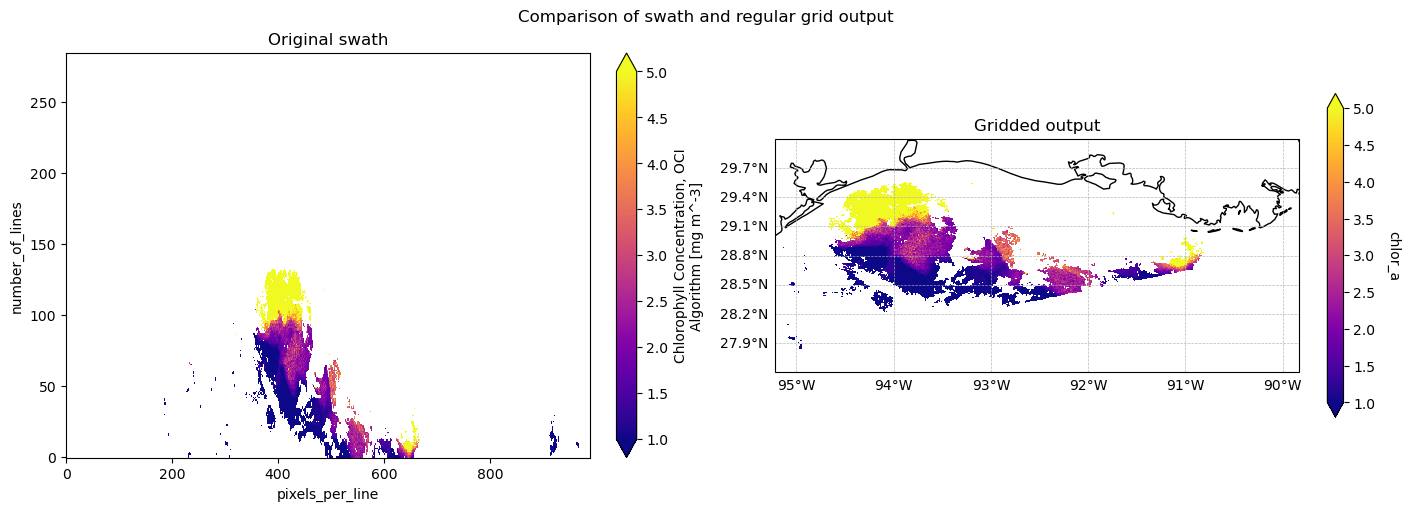

In [44]:
# Plot settings
vmin, vmax = 1, 5
cmap = 'plasma'

map_proj = ccrs.PlateCarree()
data_proj = ccrs.PlateCarree()

# Create figure
fig = plt.figure(figsize=(14, 5), constrained_layout=True)

# First subplot standard mpl axis
ax1 = fig.add_subplot(1, 2, 1)

# Second subplot cartopy axis
ax2 = fig.add_subplot(1, 2, 2, projection=map_proj)

# Original swath
da_sub.plot(ax=ax1, vmin=vmin, vmax=vmax, cmap=cmap)
ax1.set_title('Original swath')

# Regular gridded output plot using Cartopy
pc = ax2.pcolormesh(da_gridded_to_plot.x, da_gridded_to_plot.y, da_gridded_to_plot, transform=data_proj, 
                    vmin=vmin, vmax=vmax, cmap=cmap)

gl = ax2.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.9)
gl.top_labels = False
gl.right_labels = False

ax2.coastlines()

# Colorbar for cartopy plot
cb = fig.colorbar(pc, ax=ax2, shrink=0.8, extend='both')
cb.set_label('chlor_a', rotation=270, labelpad=18)

ax2.set_title(f'Gridded output')

fig.suptitle('Comparison of swath and regular grid output')

plt.show()